# End-to-End ML Pipeline for Weather Delay Prediction
This notebook handles flight data preprocessing, bulk weather data fetching, 4-way time merging, and predictive modeling.


In [32]:
import pandas as pd
import numpy as np
import os
import glob
import requests
import datetime
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
import pytz
from timezonefinder import TimezoneFinder
import math
import warnings; warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)


## Phase 1: Flight Data Preprocessing
Here we load all the CSV files, handle missing dates, drop cancellations and duplicates, and address class imbalance. If you've already run this, it will load the cached output directly.


In [33]:
# Phase 1: Initialize or Load Cache
if os.path.exists("02_flights_balanced.csv"):
    print("Found 02_flights_balanced.csv! Loading cached data...")
    flights_balanced = pd.read_csv("02_flights_balanced.csv", low_memory=False)
    
    # Check if this is an old cache without dt_local columns
    if 'crs_dep_dt_local' not in flights_balanced.columns:
        print("Old cache format detected. Generating local datetime columns...")
        def clean_time(time_val):
            if pd.isna(time_val): return '0000'
            t = int(float(time_val))
            if t >= 2400: t = 0
            return f"{t:04d}"
        
        flights_balanced['FL_DATE'] = pd.to_datetime(flights_balanced['FL_DATE'])
        flights_balanced['crs_dep_str'] = flights_balanced['CRS_DEP_TIME'].apply(clean_time)
        flights_balanced['dep_str'] = flights_balanced['DEP_TIME'].apply(clean_time)
        flights_balanced['crs_arr_str'] = flights_balanced['CRS_ARR_TIME'].apply(clean_time)
        flights_balanced['arr_str'] = flights_balanced['ARR_TIME'].apply(clean_time)
        
        flights_balanced['crs_dep_dt_local'] = pd.to_datetime(flights_balanced['FL_DATE'].dt.strftime('%Y-%m-%d') + ' ' + flights_balanced['crs_dep_str'], format='%Y-%m-%d %H%M', errors='coerce')
        flights_balanced['dep_dt_local'] = pd.to_datetime(flights_balanced['FL_DATE'].dt.strftime('%Y-%m-%d') + ' ' + flights_balanced['dep_str'], format='%Y-%m-%d %H%M', errors='coerce')
        flights_balanced['crs_arr_dt_local'] = pd.to_datetime(flights_balanced['FL_DATE'].dt.strftime('%Y-%m-%d') + ' ' + flights_balanced['crs_arr_str'], format='%Y-%m-%d %H%M', errors='coerce')
        flights_balanced['arr_dt_local'] = pd.to_datetime(flights_balanced['FL_DATE'].dt.strftime('%Y-%m-%d') + ' ' + flights_balanced['arr_str'], format='%Y-%m-%d %H%M', errors='coerce')
        flights_balanced = flights_balanced.dropna(subset=['crs_dep_dt_local', 'dep_dt_local', 'crs_arr_dt_local', 'arr_dt_local'])
        
        # Resave it in the new format
        flights_balanced.to_csv("02_flights_balanced.csv", index=False)
        print("Upgraded and re-saved 02_flights_balanced.csv.")

    # Convert string dates back to datetime objects
    date_cols = ['FL_DATE', 'crs_dep_dt_local', 'dep_dt_local', 'crs_arr_dt_local', 'arr_dt_local']
    for col in date_cols:
        if col in flights_balanced.columns:
            flights_balanced[col] = pd.to_datetime(flights_balanced[col], errors='coerce')
            
    skip_raw = True
    print(f"Loaded {len(flights_balanced):,} flights. Skipping to Phase 2.")
else:
    skip_raw = False
    print("No cached dataset found. Proceeding with raw data processing in following cells.")



Found 02_flights_balanced.csv! Loading cached data...
Loaded 177,810 flights. Skipping to Phase 2.


In [34]:
# 1. Load Data
if not skip_raw:
    flight_data_dir = r"raw-data-reduced-min-2024"
    all_files = glob.glob(os.path.join(flight_data_dir, "T_ONTIME_REPORTING_*", "T_ONTIME_REPORTING.csv"))
    
    print(f"Found {len(all_files)} files. Loading data...")
    dfs = []
    for file in all_files:
        df = pd.read_csv(file, low_memory=False)
        dfs.append(df)
    
    flights = pd.concat(dfs, ignore_index=True)
    print(f"Total flights loaded: {len(flights):,}")


In [35]:
# Rename the columns in your CSV to match the expected names in the pipeline
# rename_dict = {
#     'Reporting_Airline': 'OP_UNIQUE_CARRIER',
#     'Flight_Number_Reporting_Airline': 'OP_CARRIER_FL_NUM',
#     'FlightDate': 'FL_DATE',
#     'Cancelled': 'CANCELLED',
#     'Origin': 'ORIGIN',
#     'Dest': 'DEST',
#     'CRSDepTime': 'CRS_DEP_TIME',
#     'DepTime': 'DEP_TIME',
#     'CRSArrTime': 'CRS_ARR_TIME',
#     'ArrTime': 'ARR_TIME',
#     'WeatherDelay': 'WEATHER_DELAY',
#     'NASDelay': 'NAS_DELAY',
#     'LateAircraftDelay': 'LATE_AIRCRAFT_DELAY'
# }

# flights = flights.rename(columns=rename_dict)
# print("Columns successfully renamed to match pipeline expectations!")

In [36]:
# 2. Date Reconstruction and Cleaning
if not skip_raw:
    flights = flights.loc[:, ~flights.columns.str.contains('^Unnamed')]
    flights = flights[flights['CANCELLED'] != 1].copy()
    print(f"Flights after removing cancellations: {len(flights):,}")
    
    delay_cols = ['WEATHER_DELAY', 'NAS_DELAY', 'LATE_AIRCRAFT_DELAY']
    for col in delay_cols:
        if col in flights.columns:
            flights[col] = flights[col].fillna(0)
            
    flights['FlightDate'] = pd.to_datetime(flights[['Year', 'Month', 'DayofMonth']].rename(columns={'Year':'year', 'Month':'month', 'DayofMonth':'day'}))


In [37]:
# 3. Deduplication
if not skip_raw:
    dedup_cols = ['FL_DATE', 'OP_UNIQUE_CARRIER', 'OP_CARRIER_FL_NUM', 'ORIGIN', 'DEST']
    flights = flights.drop_duplicates(subset=dedup_cols, keep='first')
    print(f"Flights after removing duplicates: {len(flights):,}")
    flights.to_csv("01_flights_deduplicated.csv", index=False)
    print("Saved 01_flights_deduplicated.csv")


In [38]:
# 4. Balancing (Undersampling Non-Delayed Flights)
if not skip_raw:
    delayed = flights[flights['WEATHER_DELAY'] > 0]
    not_delayed = flights[flights['WEATHER_DELAY'] == 0]
    
    print(f"Delayed flights: {len(delayed):,}")
    print(f"Non-delayed flights: {len(not_delayed):,}")
    
    if len(delayed) > 0:
        not_delayed_sampled = not_delayed.sample(n=len(delayed), random_state=42)
        flights_balanced = pd.concat([delayed, not_delayed_sampled])
        flights_balanced = flights_balanced.sample(frac=1, random_state=42).reset_index(drop=True)
    else:
        print("Warning: No delayed flights found!")
        flights_balanced = flights.copy()
        
    print(f"Total flights after balancing: {len(flights_balanced):,}")


In [39]:
# 5. Time Formatting and UTC Conversion
if not skip_raw:
    def clean_time(time_val):
        if pd.isna(time_val): return '0000'
        t = int(float(time_val))
        if t >= 2400: t = 0
        return f"{t:04d}"
    
    # Drop any duplicate columns (keeps only the first 'FL_DATE' it finds)
    flights_balanced = flights_balanced.loc[:, ~flights_balanced.columns.duplicated(keep='first')]

    # Ensure the remaining FL_DATE is actually a datetime object
    flights_balanced['FL_DATE'] = pd.to_datetime(flights_balanced['FL_DATE'])

    # Now your original code will run smoothly!
    flights_balanced['crs_dep_str'] = flights_balanced['CRS_DEP_TIME'].apply(clean_time)
    flights_balanced['dep_str'] = flights_balanced['DEP_TIME'].apply(clean_time)
    flights_balanced['crs_arr_str'] = flights_balanced['CRS_ARR_TIME'].apply(clean_time)
    flights_balanced['arr_str'] = flights_balanced['ARR_TIME'].apply(clean_time)

    flights_balanced['crs_dep_dt_local'] = pd.to_datetime(flights_balanced['FL_DATE'].dt.strftime('%Y-%m-%d') + ' ' + flights_balanced['crs_dep_str'], format='%Y-%m-%d %H%M', errors='coerce')
    
    flights_balanced['crs_dep_str'] = flights_balanced['CRS_DEP_TIME'].apply(clean_time)
    flights_balanced['dep_str'] = flights_balanced['DEP_TIME'].apply(clean_time)
    flights_balanced['crs_arr_str'] = flights_balanced['CRS_ARR_TIME'].apply(clean_time)
    flights_balanced['arr_str'] = flights_balanced['ARR_TIME'].apply(clean_time)
    
    flights_balanced['crs_dep_dt_local'] = pd.to_datetime(flights_balanced['FL_DATE'].dt.strftime('%Y-%m-%d') + ' ' + flights_balanced['crs_dep_str'], format='%Y-%m-%d %H%M', errors='coerce')
    flights_balanced['dep_dt_local'] = pd.to_datetime(flights_balanced['FL_DATE'].dt.strftime('%Y-%m-%d') + ' ' + flights_balanced['dep_str'], format='%Y-%m-%d %H%M', errors='coerce')
    flights_balanced['crs_arr_dt_local'] = pd.to_datetime(flights_balanced['FL_DATE'].dt.strftime('%Y-%m-%d') + ' ' + flights_balanced['crs_arr_str'], format='%Y-%m-%d %H%M', errors='coerce')
    flights_balanced['arr_dt_local'] = pd.to_datetime(flights_balanced['FL_DATE'].dt.strftime('%Y-%m-%d') + ' ' + flights_balanced['arr_str'], format='%Y-%m-%d %H%M', errors='coerce')
    
    flights_balanced = flights_balanced.dropna(subset=['crs_dep_dt_local', 'dep_dt_local', 'crs_arr_dt_local', 'arr_dt_local'])
    
    # Save AFTER time formatting
    flights_balanced.to_csv("02_flights_balanced.csv", index=False)
    print(f"Saved 02_flights_balanced.csv with {len(flights_balanced):,} records")


## Phase 2: Bulk Weather Data Fetching
Fetch weather data for unique airports over the required date range. We no longer rely on prefix guessing, but instead map IATA to exact ICAO codes.


In [40]:
# Get unique origin and dest airports
all_required_airports = set(flights_balanced['ORIGIN'].unique()).union(set(flights_balanced['DEST'].unique()))
print(f"Total unique airports to fetch weather for: {len(all_required_airports)}")

WEATHER_DIR = "weather_data"
if not os.path.exists(WEATHER_DIR):
    os.makedirs(WEATHER_DIR)

import io

print("Downloading IATA to ICAO mapping from OurAirports...")
url = "https://davidmegginson.github.io/ourairports-data/airports.csv"
try:
    response = requests.get(url, timeout=30)
    airports_df = pd.read_csv(io.StringIO(response.text))
    us_airports = airports_df[(airports_df['iso_country'] == 'US') & (airports_df['iata_code'].notna())]
    iata_to_icao = dict(zip(us_airports['iata_code'], us_airports['ident']))
    print(f"Successfully loaded mapping for {len(iata_to_icao)} airports.")
except Exception as e:
    print(f"Warning: Could not download mapping ({e}).")
    iata_to_icao = {}

# Uncomment the following to execute the fetch. (Skipped by default to prevent accidental massive API usage)

import concurrent.futures

def fetch_single_airport(apt, year, iata_map, out_dir):
    """Worker function to fetch a single airport's data."""
    icao = iata_map.get(apt)
    
    if not icao:
        return f"Skipping {apt}: No valid ICAO code found."
        
    out_path = os.path.join(out_dir, f"{icao}_{year}.csv")
    
    # Skip if already downloaded and valid
    if os.path.exists(out_path) and os.path.getsize(out_path) > 300: 
        return f"Already have {icao}"
    
    print(f"Fetching {icao}...")
    url = (
        f"https://mesonet.agron.iastate.edu/cgi-bin/request/asos.py?"
        f"station={icao}&data=all&"
        f"year1={year}&month1=1&day1=1&"
        f"year2={year}&month2=12&day2=31&"
        f"tz=UTC&format=onlycomma&latlon=yes&missing=empty&trace=T&direct=yes&report_type=1&report_type=2"
    )
    try:
        r = requests.get(url, timeout=60)
        if r.status_code == 200:
            if len(r.text) > 300:
                with open(out_path, 'w') as f:
                    f.write(r.text)
                return f"Success {icao}"
            else:
                return f"  {icao} returned empty data."
        else:
            return f"  {icao} failed with status {r.status_code}"
    except Exception as e:
        return f"Error fetching {icao}: {e}"

def fetch_weather_bulk_fast(airports, year):
    """Manages the multithreaded downloading process."""
    print(f"Starting FAST threaded download for {year}. Using 5 concurrent workers...")
    
    # max_workers=5 means it downloads 5 files at the exact same time
    with concurrent.futures.ThreadPoolExecutor(max_workers=5) as executor:
        # Submit all tasks to the executor
        futures = [executor.submit(fetch_single_airport, apt, year, iata_to_icao, WEATHER_DIR) for apt in airports]
        
        # This just keeps the notebook cell running until all threads finish
        for future in concurrent.futures.as_completed(futures):
            # You could print(future.result()) here if you want detailed logs of every success/skip
            pass 
            
    print("Bulk download complete!")

# Execute the fast version
fetch_weather_bulk_fast(list(all_required_airports), 2024)



Total unique airports to fetch weather for: 348
Successfully loaded mapping for 2035 airports.
Starting FAST threaded download for 2024. Using 5 concurrent workers...
Fetching KABY...
Fetching KEWN...
Fetching KCMX...
Fetching KCHA...
Fetching KBWI...
Fetching KSMX...
Fetching KACV...
Fetching KMEM...
Fetching KLCH...
Fetching KBJI...
Fetching KSJT...
Fetching KDAB...
Fetching KLIT...
Fetching KMLI...
Fetching KATL...
Fetching KCOU...
Fetching KPVU...
Fetching KSCK...
Fetching KPHL...
Fetching KSTC...
Fetching KLWS...
Fetching KGPI...
Fetching KBIH...
Fetching KDAY...
Bulk download complete!


## Phase 3: Data Merging (4-Way Merge)
Merge the cached weather data into the flight rows for the 4 distinct times.


In [41]:
# Build ICAO to IATA map so we can convert downloaded weather files back to standard IATA codes for the merge
icao_to_iata = {v: k for k, v in iata_to_icao.items()} if 'iata_to_icao' in locals() else {}

# 1. Quick Pass: Extract valid airports and their coordinates
weather_files = glob.glob(os.path.join(WEATHER_DIR, "*.csv"))
valid_airports = set()
airport_coords_list = []

print("Scanning weather files to extract available airports and coordinates...")
for f in weather_files:
    filename = os.path.basename(f)
    icao_code = filename.split('_')[0]
    iata_code = icao_to_iata.get(icao_code)
    
    if not iata_code:
        iata_code = icao_code[1:] if len(icao_code) == 4 and icao_code[0] in ['K', 'P', 'T'] else icao_code
    
    try:
        # Read just the first few rows to get lat/lon quickly
        head = pd.read_csv(f, nrows=1, on_bad_lines='skip')
        if 'lat' in head.columns and 'lon' in head.columns:
            airport_coords_list.append({'AIRPORT': iata_code, 'lat': head['lat'].iloc[0], 'lon': head['lon'].iloc[0]})
            valid_airports.add(iata_code)
    except:
        continue

if not weather_files:
    print("No weather data found to merge. Please run the fetch function.")
else:
    # 2. Filter flights and apply timezones
    original_len = len(flights_balanced)
    flights_balanced = flights_balanced[
        flights_balanced['ORIGIN'].isin(valid_airports) & 
        flights_balanced['DEST'].isin(valid_airports)
    ].copy()
    print(f"Dropped {original_len - len(flights_balanced):,} flights due to missing weather data.")

    airport_coords = pd.DataFrame(airport_coords_list).drop_duplicates(subset=['AIRPORT'])

    # Map lat/lon to Timezones
    from timezonefinder import TimezoneFinder
    tf = TimezoneFinder()
    tz_dict = {}
    for _, row in airport_coords.iterrows():
        try:
            tz = tf.timezone_at(lng=row['lon'], lat=row['lat'])
            if tz: tz_dict[row['AIRPORT']] = tz
        except:
            continue

    # Apply timezones to flight dataset
    flights_balanced['ORIGIN_TZ'] = flights_balanced['ORIGIN'].map(tz_dict)
    flights_balanced['DEST_TZ'] = flights_balanced['DEST'].map(tz_dict)
    flights_balanced = flights_balanced.dropna(subset=['ORIGIN_TZ', 'DEST_TZ'])

    def convert_to_utc(dt_series, tz_series):
        utc_series = pd.Series(index=dt_series.index, dtype='datetime64[ns, UTC]')
        for tz, group in dt_series.groupby(tz_series):
            local_time = group.dt.tz_localize(tz, ambiguous='NaT', nonexistent='NaT')
            utc_series.loc[group.index] = local_time.dt.tz_convert('UTC')
        return utc_series

    print("Converting naive flight times to UTC using exact airport coordinates...")
    flights_balanced['ORIGIN_CRS_DEP_UTC'] = convert_to_utc(flights_balanced['crs_dep_dt_local'], flights_balanced['ORIGIN_TZ']).dt.tz_localize(None)
    flights_balanced['ORIGIN_DEP_UTC'] = convert_to_utc(flights_balanced['dep_dt_local'], flights_balanced['ORIGIN_TZ']).dt.tz_localize(None)
    flights_balanced['DEST_CRS_ARR_UTC'] = convert_to_utc(flights_balanced['crs_arr_dt_local'], flights_balanced['DEST_TZ']).dt.tz_localize(None)
    flights_balanced['DEST_ARR_UTC'] = convert_to_utc(flights_balanced['arr_dt_local'], flights_balanced['DEST_TZ']).dt.tz_localize(None)

    flights_balanced = flights_balanced.dropna(subset=['ORIGIN_CRS_DEP_UTC', 'ORIGIN_DEP_UTC', 'DEST_CRS_ARR_UTC', 'DEST_ARR_UTC'])

    # We MUST preserve the original index to stitch the chunks back together
    flights_balanced = flights_balanced.reset_index(drop=True)
    flights_balanced.to_csv("03_flights_time_formatted.csv", index=False)
    print("Saved 03_flights_time_formatted.csv")


Scanning weather files to extract available airports and coordinates...
Dropped 29,449 flights due to missing weather data.
Converting naive flight times to UTC using exact airport coordinates...
Saved 03_flights_time_formatted.csv


## Phase 3.5: Memory-Efficient Airport-by-Airport Merge
Here we iterate through each weather file, matching its readings to the flights associated with that airport to prevent Out of Memory errors.


In [42]:
if not weather_files:
    print("Skipping merge because no weather files exist.")
else:
    # Get columns from a sample weather file
    sample_wdf = pd.read_csv(weather_files[0], nrows=1, on_bad_lines='skip', low_memory=False)
    non_feat = ['station', 'valid', 'lon', 'lat', 'AIRPORT', 'WEATHER_UTC']
    feat_cols = [c for c in sample_wdf.columns if c not in non_feat]

    rename_o_crs = {c: f'O_CRS_{c}' for c in feat_cols}
    rename_o_act = {c: f'O_ACT_{c}' for c in feat_cols}
    rename_d_crs = {c: f'D_CRS_{c}' for c in feat_cols}
    rename_d_act = {c: f'D_ACT_{c}' for c in feat_cols}

    origin_chunks = []
    dest_chunks = []

    print(f"Starting chunked merge across {len(weather_files)} airports...")

    for f in weather_files:
        filename = os.path.basename(f)
        icao_code = filename.split('_')[0]
        iata_code = icao_to_iata.get(icao_code)
        if not iata_code:
            iata_code = icao_code[1:] if len(icao_code) == 4 and icao_code[0] in ['K', 'P', 'T'] else icao_code
        
        # Check if this airport actually has flights associated with it
        has_origin = (flights_balanced['ORIGIN'] == iata_code).any()
        has_dest = (flights_balanced['DEST'] == iata_code).any()
        
        if not (has_origin or has_dest):
            continue # Skip loading weather if no flights use it
            
        # Load this airport's weather
        wdf = pd.read_csv(f, on_bad_lines='skip', low_memory=False)
        wdf['WEATHER_UTC'] = pd.to_datetime(wdf['valid']).dt.tz_localize(None)
        wdf = wdf.sort_values('WEATHER_UTC')
        wdf = wdf.replace({'M': pd.NA, 'T': 0.001})
        for col in feat_cols:
            if col in wdf.columns:
                wdf[col] = pd.to_numeric(wdf[col], errors='coerce')
                
        # Forward fill up to 12 rows (approx 1 hour of 5-min intervals) to handle fragmented sensor reports
        wdf[feat_cols] = wdf[feat_cols].ffill(limit=12)
                
        # --- Origin Merge ---
        if has_origin:
            origin_flights = flights_balanced[flights_balanced['ORIGIN'] == iata_code][['ORIGIN_CRS_DEP_UTC', 'ORIGIN_DEP_UTC']].copy()
            origin_flights['original_index'] = origin_flights.index
            
            m1 = pd.merge_asof(
                origin_flights.sort_values('ORIGIN_CRS_DEP_UTC'), 
                wdf[['WEATHER_UTC'] + feat_cols].rename(columns=rename_o_crs),
                left_on='ORIGIN_CRS_DEP_UTC', right_on='WEATHER_UTC', direction='backward'
            ).drop(columns=['WEATHER_UTC'])
            
            m2 = pd.merge_asof(
                m1.sort_values('ORIGIN_DEP_UTC'), 
                wdf[['WEATHER_UTC'] + feat_cols].rename(columns=rename_o_act),
                left_on='ORIGIN_DEP_UTC', right_on='WEATHER_UTC', direction='backward'
            ).drop(columns=['WEATHER_UTC'])
            
            m2 = m2.set_index('original_index')
            feat_cols_o = [c for c in m2.columns if c.startswith('O_')]
            origin_chunks.append(m2[feat_cols_o])

        # --- Dest Merge ---
        if has_dest:
            dest_flights = flights_balanced[flights_balanced['DEST'] == iata_code][['DEST_CRS_ARR_UTC', 'DEST_ARR_UTC']].copy()
            dest_flights['original_index'] = dest_flights.index
            
            m3 = pd.merge_asof(
                dest_flights.sort_values('DEST_CRS_ARR_UTC'), 
                wdf[['WEATHER_UTC'] + feat_cols].rename(columns=rename_d_crs),
                left_on='DEST_CRS_ARR_UTC', right_on='WEATHER_UTC', direction='backward'
            ).drop(columns=['WEATHER_UTC'])
            
            m4 = pd.merge_asof(
                m3.sort_values('DEST_ARR_UTC'), 
                wdf[['WEATHER_UTC'] + feat_cols].rename(columns=rename_d_act),
                left_on='DEST_ARR_UTC', right_on='WEATHER_UTC', direction='backward'
            ).drop(columns=['WEATHER_UTC'])
            
            m4 = m4.set_index('original_index')
            feat_cols_d = [c for c in m4.columns if c.startswith('D_')]
            dest_chunks.append(m4[feat_cols_d])

    print("Stitching all matched weather features back to the flights dataset...")
    all_origin_features = pd.concat(origin_chunks) if origin_chunks else pd.DataFrame()
    all_dest_features = pd.concat(dest_chunks) if dest_chunks else pd.DataFrame()

    # Join by the original flight index
    final_merged = flights_balanced.join(all_origin_features).join(all_dest_features)

    final_merged.to_csv("04_flights_weather_merged.csv", index=False)
    print("Merged dataset created successfully and saved as 04_flights_weather_merged.csv!")


Starting chunked merge across 319 airports...
Stitching all matched weather features back to the flights dataset...
Merged dataset created successfully and saved as 04_flights_weather_merged.csv!


## Phase 3.75: Data Imputation
Handling null values based on ASOS non-event characteristics to preserve training data.

In [43]:
# If running this cell independently, uncomment the following line:
# final_merged = pd.read_csv("04_flights_weather_merged.csv", low_memory=False)

print(f"Original merged rows: {len(final_merged)}")

# List of all prefixes to process
prefixes = ['O_CRS_', 'D_CRS_', 'O_ACT_', 'D_ACT_']

df_imputed = final_merged.copy()

# 1. Event-Driven Imputation
for p in prefixes:
    # Gusts
    if f'{p}gust' in df_imputed.columns:
        df_imputed[f'{p}gust'] = df_imputed[f'{p}gust'].fillna(0)
    
    # Sky Coverage
    for i in range(1, 5):
        if f'{p}skyc{i}' in df_imputed.columns:
            df_imputed[f'{p}skyc{i}'] = df_imputed[f'{p}skyc{i}'].fillna('CLR')
        if f'{p}skyl{i}' in df_imputed.columns:
            # 0 indicates no clouds / clear sky
            df_imputed[f'{p}skyl{i}'] = df_imputed[f'{p}skyl{i}'].fillna(0)
            
    # Present Weather Codes
    if f'{p}wxcodes' in df_imputed.columns:
        df_imputed[f'{p}wxcodes'] = df_imputed[f'{p}wxcodes'].fillna('NP')
        
    # Peak Wind
    if f'{p}peak_wind_gust' in df_imputed.columns:
        df_imputed[f'{p}peak_wind_gust'] = df_imputed[f'{p}peak_wind_gust'].fillna(0)
    if f'{p}peak_wind_drct' in df_imputed.columns:
        df_imputed[f'{p}peak_wind_drct'] = df_imputed[f'{p}peak_wind_drct'].fillna(0)
    if f'{p}peak_wind_time' in df_imputed.columns:
        df_imputed[f'{p}peak_wind_time'] = df_imputed[f'{p}peak_wind_time'].fillna('0000')
        
    # Ice Accretion
    for hr in ['1hr', '3hr', '6hr']:
        if f'{p}ice_accretion_{hr}' in df_imputed.columns:
            df_imputed[f'{p}ice_accretion_{hr}'] = df_imputed[f'{p}ice_accretion_{hr}'].fillna(0)
            
    # Precipitation (1-hour)
    if f'{p}p01i' in df_imputed.columns:
        df_imputed[f'{p}p01i'] = df_imputed[f'{p}p01i'].fillna(0)

# 2. Continuous Element Imputation
continuous_cols = []
for p in prefixes:
    continuous_cols.extend([f'{p}tmpf', f'{p}dwpf', f'{p}relh', f'{p}drct', f'{p}sknt', f'{p}alti', f'{p}mslp', f'{p}vsby', f'{p}feel', f'{p}snowdepth'])

existing_cont_cols = [c for c in continuous_cols if c in df_imputed.columns]
df_imputed[existing_cont_cols] = df_imputed[existing_cont_cols].ffill()

# Drop rows only if essential continuous elements are still missing
df_imputed = df_imputed.dropna(subset=existing_cont_cols)
print(f"Rows after imputation and continuous variable dropna: {len(df_imputed)}")

# 3. One-hot Encoding for wxcodes
wx_cols = [c for c in df_imputed.columns if 'wxcodes' in c]
if wx_cols:
    df_imputed = pd.get_dummies(df_imputed, columns=wx_cols, dummy_na=False)

print(f"Total columns after one-hot encoding: {len(df_imputed.columns)}")

# Update final_merged to be the imputed dataframe so subsequent EDA cells use it
final_merged = df_imputed
# Also save just in case
final_merged.to_csv("05_modeling_ready_data.csv", index=False)
print("Saved imputed dataset to 05_modeling_ready_data.csv")


Original merged rows: 148354
Rows after imputation and continuous variable dropna: 148053
Total columns after one-hot encoding: 165
Saved imputed dataset to 05_modeling_ready_data.csv


In [44]:
import pandas as pd
import os

print("--- PHASE 3.8: FEATURE ENGINEERING ---")

# 1. Load the cleanly imputed data
if os.path.exists("05_modeling_ready_data.csv"):
    df = pd.read_csv("05_modeling_ready_data.csv", low_memory=False)
    print(f"Loaded imputed data. Original column count: {len(df.columns)}")

    # 2. Engineering: Visibility Drop (Invert visibility so higher number = worse visibility)
    if 'O_CRS_vsby' in df.columns:
        df['O_CRS_vsby_drop'] = 10.0 - df['O_CRS_vsby']
    if 'D_CRS_vsby' in df.columns:
        df['D_CRS_vsby_drop'] = 10.0 - df['D_CRS_vsby']

    # 3. Engineering: Wind Severity (Multiplying sustained wind by gusts)
    if 'O_CRS_sknt' in df.columns and 'O_CRS_gust' in df.columns:
        df['O_CRS_wind_severity'] = df['O_CRS_sknt'] * df['O_CRS_gust']
    if 'D_CRS_sknt' in df.columns and 'D_CRS_gust' in df.columns:
        df['D_CRS_wind_severity'] = df['D_CRS_sknt'] * df['D_CRS_gust']

    # 4. Pruning the Noise: Drop redundant atmospheric data
    noise_columns = [
        'O_CRS_mslp', 'D_CRS_mslp', 'O_ACT_mslp', 'D_ACT_mslp', 
        'O_CRS_skyl2', 'O_CRS_skyl3', 'O_CRS_skyl4',
        'D_CRS_skyl2', 'D_CRS_skyl3', 'D_CRS_skyl4',
        'O_ACT_skyl2', 'O_ACT_skyl3', 'O_ACT_skyl4',
        'D_ACT_skyl2', 'D_ACT_skyl3', 'D_ACT_skyl4'
    ]
    
    df = df.drop(columns=noise_columns, errors='ignore')
    print(f"Columns after engineering and pruning: {len(df.columns)}")

    # 5. Save the upgraded dataset
    df.to_csv("06_engineered_data.csv", index=False)
    print("Successfully saved engineered dataset to 06_engineered_data.csv!")
    
else:
    print("Error: Could not find '05_modeling_ready_data.csv'. Please make sure Phase 3.75 ran successfully.")

--- PHASE 3.8: FEATURE ENGINEERING ---
Loaded imputed data. Original column count: 165
Columns after engineering and pruning: 153
Successfully saved engineered dataset to 06_engineered_data.csv!


## Phase 4: EDA & Modeling
Analyze features and train baseline models.


In [45]:
import pandas as pd
import numpy as np
import os
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

print("--- INITIALIZING FINAL PIPELINE ---")

# 1. Load the Data (It will use 06 if you saved it, otherwise falls back to 05)
file_name = "06_engineered_data.csv" if os.path.exists("06_engineered_data.csv") else "05_modeling_ready_data.csv"
df = pd.read_csv(file_name, low_memory=False)

# 2. Prune unnecessary columns
columns_to_drop = [
    "O_CRS_metar", "D_CRS_metar", "O_CRS_skyc1", "O_CRS_skyc2", "O_CRS_skyc3", "O_CRS_skyc4",
    "D_CRS_skyc1", "D_CRS_skyc2", "D_CRS_skyc3", "D_CRS_skyc4", "O_CRS_wxcodes_NP", "D_CRS_wxcodes_NP"
]
df = df.drop(columns=columns_to_drop, errors='ignore')

# 3. Create df_model by dropping rows with missing essential weather data
weather_feats = [c for c in df.columns if any(x in c for x in ['O_CRS', 'D_CRS'])]
if 'WEATHER_DELAY' in weather_feats: 
    weather_feats.remove('WEATHER_DELAY')
    
df_model = df.dropna(subset=weather_feats + ['WEATHER_DELAY']).copy()

# ---------------------------------------------------------
# 4. ENGINEER THE AIRPORT CONGESTION FEATURE
# ---------------------------------------------------------
print("Engineering Airport Congestion feature...")
df_model['ORIGIN_CRS_DEP_UTC'] = pd.to_datetime(df_model['ORIGIN_CRS_DEP_UTC'])
df_model = df_model.sort_values(by=['ORIGIN', 'ORIGIN_CRS_DEP_UTC'])

# Safely find the exact departure delay column name your dataset is using
if 'DEP_DELAY_NEW' in df_model.columns:
    delay_col = 'DEP_DELAY_NEW'
elif 'DepDelayMinutes' in df_model.columns:
    delay_col = 'DepDelayMinutes'
else:
    delay_col = 'DepDelay' 

# Calculate the 2-hour rolling average of delays at that specific airport
df_model = df_model.set_index('ORIGIN_CRS_DEP_UTC')
df_model['Airport_Congestion_2hr'] = (
    df_model.groupby('ORIGIN')[delay_col]
    .rolling('2h', closed='left')
    .mean()
    .reset_index(level=0, drop=True)
)
df_model = df_model.reset_index()
df_model['Airport_Congestion_2hr'] = df_model['Airport_Congestion_2hr'].fillna(0)
print("Congestion feature successfully created!")


# ---------------------------------------------------------
# 5. FINAL XGBOOST CLASSIFICATION MODEL
# ---------------------------------------------------------
print("Training Final XGBoost Model...")

# Bring back time features, and add the new Congestion feature
time_feats = ['Month', 'DayOfWeek', 'CRS_DEP_TIME', 'Airport_Congestion_2hr']
all_features = weather_feats + [f for f in time_feats if f in df_model.columns]

X_final = df_model[all_features]
# The FAA 15-Minute Threshold
y_binary = (df_model['WEATHER_DELAY'] > 15).astype(int)

# Split and Scale
X_train_bin, X_test_bin, y_train_bin, y_test_bin = train_test_split(X_final, y_binary, test_size=0.2, random_state=42)

scaler_X_final = StandardScaler()
X_train_bin_scaled = scaler_X_final.fit_transform(X_train_bin)
X_test_bin_scaled = scaler_X_final.transform(X_test_bin)

# Calculate exact imbalance ratio
imbalance_ratio = float(np.sum(y_train_bin == 0)) / np.sum(y_train_bin == 1)

# Train XGBoost
xgb_final = XGBClassifier(
    n_estimators=300, 
    learning_rate=0.05, 
    max_depth=6, 
    scale_pos_weight=imbalance_ratio, 
    random_state=42, 
    n_jobs=-1
)
xgb_final.fit(X_train_bin_scaled, y_train_bin)

y_pred_final = xgb_final.predict(X_test_bin_scaled)

print("\n================ FINAL RESULTS ================")
print(f"Accuracy: {accuracy_score(y_test_bin, y_pred_final) * 100:.2f}%")
print("\nDetailed Report:")
print(classification_report(y_test_bin, y_pred_final))
print("===============================================")

--- INITIALIZING FINAL PIPELINE ---
Engineering Airport Congestion feature...
Congestion feature successfully created!
Training Final XGBoost Model...

================ FINAL RESULTS ================
Accuracy: 73.61%

Detailed Report:
              precision    recall  f1-score   support

           0       0.82      0.74      0.78     18738
           1       0.62      0.73      0.67     10873

    accuracy                           0.74     29611
   macro avg       0.72      0.73      0.72     29611
weighted avg       0.75      0.74      0.74     29611



In [46]:
import numpy as np

print(f"Original column count: {len(df.columns)}")

# 1. Feature Engineering: Create Severity Metrics
# ASOS visibility tops out at 10 miles. This inverts it so higher number = worse visibility
if 'O_CRS_vsby' in df.columns:
    df['O_CRS_vsby_drop'] = 10.0 - df['O_CRS_vsby']
if 'D_CRS_vsby' in df.columns:
    df['D_CRS_vsby_drop'] = 10.0 - df['D_CRS_vsby']

# Wind Severity: Multiplying sustained wind by gusts
if 'O_CRS_sknt' in df.columns and 'O_CRS_gust' in df.columns:
    df['O_CRS_wind_severity'] = df['O_CRS_sknt'] * df['O_CRS_gust']
if 'D_CRS_sknt' in df.columns and 'D_CRS_gust' in df.columns:
    df['D_CRS_wind_severity'] = df['D_CRS_sknt'] * df['D_CRS_gust']

# 2. Prune the Noise: Drop redundant atmospheric data
# Keeping only the lowest cloud layer (skyl1) and standardizing on altimeter pressure (alti)
noise_columns = [
    'O_CRS_mslp', 'D_CRS_mslp', 'O_ACT_mslp', 'D_ACT_mslp', # Redundant with alti
    'O_CRS_skyl2', 'O_CRS_skyl3', 'O_CRS_skyl4',
    'D_CRS_skyl2', 'D_CRS_skyl3', 'D_CRS_skyl4',
    'O_ACT_skyl2', 'O_ACT_skyl3', 'O_ACT_skyl4',
    'D_ACT_skyl2', 'D_ACT_skyl3', 'D_ACT_skyl4'
]

df = df.drop(columns=noise_columns, errors='ignore')
print(f"Columns after engineering and pruning: {len(df.columns)}")

Original column count: 141
Columns after engineering and pruning: 141


In [47]:
# Load final dataset
if os.path.exists("05_modeling_ready_data.csv"):
    df = pd.read_csv("05_modeling_ready_data.csv")
    
    print("================ ALL COLUMNS IN FINAL DATASET ================")
    for i, col in enumerate(df.columns):
        print(f"{i:3d}: {col}")
    print("==============================================================")
    
    # --- DROP COLUMNS HERE ---
    columns_to_drop = [
        "O_CRS_metar", "D_CRS_metar", "O_CRS_skyc1", "O_CRS_skyc2", "O_CRS_skyc3", "O_CRS_skyc4",
        "D_CRS_skyc1", "D_CRS_skyc2", "D_CRS_skyc3", "D_CRS_skyc4", "O_CRS_wxcodes_NP", "D_CRS_wxcodes_NP"
    ]
    if columns_to_drop:
        df = df.drop(columns=columns_to_drop, errors='ignore')
        print(f"\nDropped {len(columns_to_drop)} columns. Remaining columns: {len(df.columns)}")
    # -------------------------
    
    # Basic EDA: Distributions of Delay Columns
    # delay_columns_to_plot = [ ... ]
    # ... (Kept commented out for your convenience) ...

    # Basic EDA: Correlation (Currently Disabled)
    # ... (Kept commented out for your convenience) ...

    import numpy as np
    from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score
    from sklearn.model_selection import train_test_split
    from sklearn.preprocessing import StandardScaler
    
    # Modeling Data Prep
    weather_feats = [c for c in df.columns if any(x in c for x in ['O_CRS', 'D_CRS'])]
    if 'WEATHER_DELAY' in weather_feats: 
        weather_feats.remove('WEATHER_DELAY')
        
    df_model = df.dropna(subset=weather_feats + ['WEATHER_DELAY'])
    X = df_model[weather_feats]
    
    # --- STEP 2: LOG-TRANSFORM THE TARGET ---
    y_log = np.log1p(df_model['WEATHER_DELAY'])
    
    X_train, X_test, y_train_log, y_test_log = train_test_split(X, y_log, test_size=0.2, random_state=42)
    
    # Decompress the test set back to standard minutes for accurate final evaluation
    y_test_minutes = np.expm1(y_test_log)
    
    # Scale Features (X) ONLY! 
    scaler_X = StandardScaler()
    X_train_scaled = scaler_X.fit_transform(X_train)
    X_test_scaled = scaler_X.transform(X_test)
    
    
    # --- Ensemble Tree Regressor ---
    from sklearn.ensemble import RandomForestRegressor
    rf = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
    rf.fit(X_train_scaled, y_train_log) # Train on log-space
    
    y_pred_log_rf = rf.predict(X_test_scaled)
    y_pred_rf = np.expm1(y_pred_log_rf) # Decompress predictions
    
    print("--- Ensemble Tree Results ---")
    print(f"RMSE: {root_mean_squared_error(y_test_minutes, y_pred_rf):.2f}")
    print(f"MAE: {mean_absolute_error(y_test_minutes, y_pred_rf):.2f}")
    print(f"R2: {r2_score(y_test_minutes, y_pred_rf):.4f}\n")
    
    
    # --- Linear Regression ---
    from sklearn.linear_model import LinearRegression
    lr = LinearRegression()
    lr.fit(X_train_scaled, y_train_log) # Train on log-space
    
    y_pred_log_lr = lr.predict(X_test_scaled)
    y_pred_lr = np.expm1(y_pred_log_lr) # Decompress predictions
    
    print("--- Linear Regression Results ---")
    print(f"RMSE: {root_mean_squared_error(y_test_minutes, y_pred_lr):.2f}")
    print(f"MAE: {mean_absolute_error(y_test_minutes, y_pred_lr):.2f}")
    print(f"R2: {r2_score(y_test_minutes, y_pred_lr):.4f}\n")
    
    
    # --- Support Vector Machine (SVR) ---
    from sklearn.svm import SVR
    
    # 1. Subset the training data to 10k samples
    subset_idx = np.random.choice(len(X_train_scaled), min(10000, len(X_train_scaled)), replace=False)
    
    # 2. Adjust epsilon for log space (0.1 instead of 10.0)
    svr = SVR(kernel='rbf', C=1.0, epsilon=0.1)
    svr.fit(X_train_scaled[subset_idx], y_train_log.iloc[subset_idx])
    
    y_pred_log_svr = svr.predict(X_test_scaled)
    y_pred_svr = np.expm1(y_pred_log_svr)
    
    print("--- SVM Results ---")
    print(f"RMSE: {root_mean_squared_error(y_test_minutes, y_pred_svr):.2f}")
    print(f"MAE: {mean_absolute_error(y_test_minutes, y_pred_svr):.2f}")
    print(f"R2: {r2_score(y_test_minutes, y_pred_svr):.4f}\n")
    
    
    # --- Simple Neural Network (MLPRegressor) ---
    from sklearn.neural_network import MLPRegressor
    mlp = MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42)
    mlp.fit(X_train_scaled, y_train_log) # Train on log-space
    
    y_pred_log_mlp = mlp.predict(X_test_scaled)
    y_pred_mlp = np.expm1(y_pred_log_mlp)
    
    print("--- Neural Network Results ---")
    print(f"RMSE: {root_mean_squared_error(y_test_minutes, y_pred_mlp):.2f}")
    print(f"MAE: {mean_absolute_error(y_test_minutes, y_pred_mlp):.2f}")
    print(f"R2: {r2_score(y_test_minutes, y_pred_mlp):.4f}\n")

    # --- XGBoost Regressor ---
    from xgboost import XGBRegressor

    # XGBoost handles tabular data and extreme outliers much better than standard models
    xgb = XGBRegressor(
        n_estimators=300, 
        learning_rate=0.05, 
        max_depth=6, 
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42, 
        n_jobs=-1
    )

    xgb.fit(X_train_scaled, y_train_log) # Train on log-space

    y_pred_log_xgb = xgb.predict(X_test_scaled)
    y_pred_xgb = np.expm1(y_pred_log_xgb) # Decompress predictions

    print("--- XGBoost Results ---")
    print(f"RMSE: {root_mean_squared_error(y_test_minutes, y_pred_xgb):.2f}")
    print(f"MAE: {mean_absolute_error(y_test_minutes, y_pred_xgb):.2f}")
    print(f"R2: {r2_score(y_test_minutes, y_pred_xgb):.4f}\n")

================ ALL COLUMNS IN FINAL DATASET ================
  0: Year
  1: Quarter
  2: Month
  3: DayofMonth
  4: DayOfWeek
  5: FL_DATE
  6: OP_UNIQUE_CARRIER
  7: Tail_Number
  8: OP_CARRIER_FL_NUM
  9: ORIGIN
 10: OriginCityName
 11: OriginState
 12: OriginStateName
 13: DEST
 14: DestCityName
 15: DestState
 16: DestStateName
 17: CRS_DEP_TIME
 18: DEP_TIME
 19: DepDelay
 20: DepDelayMinutes
 21: CRS_ARR_TIME
 22: ARR_TIME
 23: ArrDelay
 24: ArrDelayMinutes
 25: CANCELLED
 26: CancellationCode
 27: Diverted
 28: CRSElapsedTime
 29: ActualElapsedTime
 30: AirTime
 31: Flights
 32: Distance
 33: CarrierDelay
 34: WEATHER_DELAY
 35: NAS_DELAY
 36: SecurityDelay
 37: LATE_AIRCRAFT_DELAY
 38: FlightDate
 39: crs_dep_str
 40: dep_str
 41: crs_arr_str
 42: arr_str
 43: crs_dep_dt_local
 44: dep_dt_local
 45: crs_arr_dt_local
 46: arr_dt_local
 47: ORIGIN_TZ
 48: DEST_TZ
 49: ORIGIN_CRS_DEP_UTC
 50: ORIGIN_DEP_UTC
 51: DEST_CRS_ARR_UTC
 52: DEST_ARR_UTC
 53: O_CRS_tmpf
 54: O_CRS_dwpf


In [48]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

# 1. Bring back the critical time features!
time_feats = ['Month', 'DayOfWeek', 'CRS_DEP_TIME']
all_features = weather_feats + [f for f in time_feats if f in df_model.columns]

X_upgraded = df_model[all_features]
y_binary = (df_model['WEATHER_DELAY'] > 15).astype(int)

# 2. Split and Scale
X_train_bin, X_test_bin, y_train_bin, y_test_bin = train_test_split(X_upgraded, y_binary, test_size=0.2, random_state=42)

scaler_X_upgraded = StandardScaler()
X_train_bin_scaled = scaler_X_upgraded.fit_transform(X_train_bin)
X_test_bin_scaled = scaler_X_upgraded.transform(X_test_bin)

# 3. Calculate the exact imbalance ratio to fix the conservative predictions
imbalance_ratio = float(np.sum(y_train_bin == 0)) / np.sum(y_train_bin == 1)
print(f"Applying Class Weight Ratio: {imbalance_ratio:.2f}")

# 4. Train the aggressively weighted XGBoost
xgb_clf = XGBClassifier(
    n_estimators=300, 
    learning_rate=0.05, 
    max_depth=6, 
    scale_pos_weight=imbalance_ratio, # Forces the model to care about Class 1
    random_state=42, 
    n_jobs=-1
)
xgb_clf.fit(X_train_bin_scaled, y_train_bin)

y_pred_bin = xgb_clf.predict(X_test_bin_scaled)

print("--- UPGRADED XGBoost CLASSIFICATION ---")
print(f"Accuracy: {accuracy_score(y_test_bin, y_pred_bin) * 100:.2f}%")
print("\nDetailed Report:")
print(classification_report(y_test_bin, y_pred_bin))

Applying Class Weight Ratio: 1.73
--- UPGRADED XGBoost CLASSIFICATION ---
Accuracy: 72.35%

Detailed Report:
              precision    recall  f1-score   support

           0       0.82      0.72      0.77     18675
           1       0.60      0.73      0.66     10936

    accuracy                           0.72     29611
   macro avg       0.71      0.72      0.71     29611
weighted avg       0.74      0.72      0.73     29611



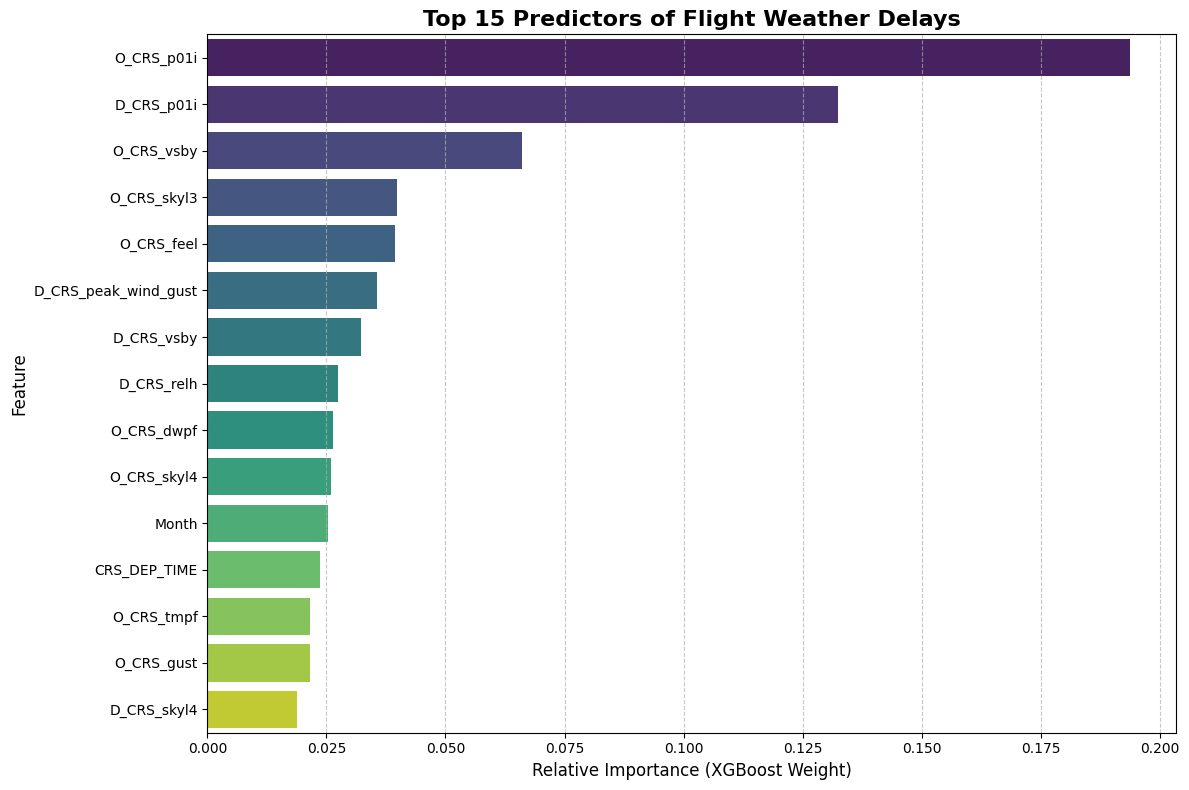

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Extract the feature importances from your trained XGBoost model
importances = xgb_clf.feature_importances_
feature_names = X_upgraded.columns

# 2. Create a DataFrame and sort it by importance
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# 3. Keep only the top 15 features so the chart isn't cluttered
top_features = importance_df.head(15)

# 4. Plot the results
plt.figure(figsize=(12, 8))
sns.barplot(
    x='Importance', 
    y='Feature', 
    data=top_features, 
    palette='viridis' # A professional, colorblind-friendly palette
)

# 5. Format the chart for a presentation slide
plt.title('Top 15 Predictors of Flight Weather Delays', fontsize=16, fontweight='bold')
plt.xlabel('Relative Importance (XGBoost Weight)', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()

# Show the plot
plt.show()

In [50]:
import pandas as pd
import numpy as np
import os
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

print("--- INITIALIZING THE ULTIMATE REGRESSION PIPELINE ---")

# 1. Load the BEST data
file_name = "06_engineered_data.csv" if os.path.exists("06_engineered_data.csv") else "05_modeling_ready_data.csv"
df = pd.read_csv(file_name, low_memory=False)

columns_to_drop = [
    "O_CRS_metar", "D_CRS_metar", "O_CRS_skyc1", "O_CRS_skyc2", "O_CRS_skyc3", "O_CRS_skyc4",
    "D_CRS_skyc1", "D_CRS_skyc2", "D_CRS_skyc3", "D_CRS_skyc4", "O_CRS_wxcodes_NP", "D_CRS_wxcodes_NP"
]
df = df.drop(columns=columns_to_drop, errors='ignore')

weather_feats = [c for c in df.columns if any(x in c for x in ['O_CRS', 'D_CRS'])]
if 'WEATHER_DELAY' in weather_feats: 
    weather_feats.remove('WEATHER_DELAY')
df_model = df.dropna(subset=weather_feats + ['WEATHER_DELAY']).copy()

# ---------------------------------------------------------
# 2. FEATURE 1: AIRPORT CONGESTION
# ---------------------------------------------------------
print("Engineering Airport Congestion feature...")
df_model['ORIGIN_CRS_DEP_UTC'] = pd.to_datetime(df_model['ORIGIN_CRS_DEP_UTC'])
df_model = df_model.sort_values(by=['ORIGIN', 'ORIGIN_CRS_DEP_UTC'])

delay_col = 'DEP_DELAY_NEW' if 'DEP_DELAY_NEW' in df_model.columns else 'DepDelayMinutes' if 'DepDelayMinutes' in df_model.columns else 'DepDelay'

df_model = df_model.set_index('ORIGIN_CRS_DEP_UTC')
df_model['Airport_Congestion_2hr'] = (
    df_model.groupby('ORIGIN')[delay_col]
    .rolling('2h', closed='left')
    .mean()
    .reset_index(level=0, drop=True)
)
df_model = df_model.reset_index()
df_model['Airport_Congestion_2hr'] = df_model['Airport_Congestion_2hr'].fillna(0)

# ---------------------------------------------------------
# 3. FEATURE 2: PREVIOUS LEG DELAY
# ---------------------------------------------------------
print("Tracking physical aircraft to calculate Previous Leg Delay...")

# Safely find the exact Tail Number column name
if 'TAIL_NUM' in df_model.columns:
    tail_col = 'TAIL_NUM'
elif 'Tail_Number' in df_model.columns:
    tail_col = 'Tail_Number'
elif 'tail_num' in df_model.columns:
    tail_col = 'tail_num'
else:
    # If the physical plane ID is completely missing, fallback to the flight number
    tail_col = 'OP_CARRIER_FL_NUM' 

# Safely find the exact Arrival Delay column name
if 'ARR_DELAY_NEW' in df_model.columns:
    arr_delay_col = 'ARR_DELAY_NEW'
elif 'ARR_DELAY' in df_model.columns:
    arr_delay_col = 'ARR_DELAY'
elif 'ArrDelayMinutes' in df_model.columns:
    arr_delay_col = 'ArrDelayMinutes'
else:
    arr_delay_col = 'ArrDelay'

print(f"Found columns: Using '{tail_col}' and '{arr_delay_col}'")

# Sort chronologically by the physical airplane
df_model = df_model.sort_values(by=[tail_col, 'ORIGIN_CRS_DEP_UTC'])

# Shift the arrival delay down one row per airplane
df_model['Previous_Leg_Delay'] = df_model.groupby(tail_col)[arr_delay_col].shift(1)

# If it's the first flight of the dataset for that plane, fill with 0
df_model['Previous_Leg_Delay'] = df_model['Previous_Leg_Delay'].fillna(0)


# ---------------------------------------------------------
# 4. THE REGRESSION SAVERS: OUTLIER CAP & LOG TRANSFORM
# ---------------------------------------------------------
print("Applying Outlier Capping and Log-Transformation...")
df_model['WEATHER_DELAY_CAPPED'] = df_model['WEATHER_DELAY'].clip(upper=180)
y_log = np.log1p(df_model['WEATHER_DELAY_CAPPED'])

# ---------------------------------------------------------
# 5. FINAL XGBOOST REGRESSION MODEL
# ---------------------------------------------------------
print("Training Final XGBoost Regressor...")
time_feats = ['Month', 'DayOfWeek', 'CRS_DEP_TIME', 'Airport_Congestion_2hr', 'Previous_Leg_Delay']
all_features = weather_feats + [f for f in time_feats if f in df_model.columns]

X_final = df_model[all_features]

X_train, X_test, y_train_log, y_test_log = train_test_split(X_final, y_log, test_size=0.2, random_state=42)

scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

# We need the true uncapped, un-logged minutes to test against reality at the very end
_, _, _, y_test_true_minutes = train_test_split(X_final, df_model['WEATHER_DELAY'], test_size=0.2, random_state=42)

xgb_reg = XGBRegressor(
    n_estimators=300, 
    learning_rate=0.05, 
    max_depth=6, 
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42, 
    n_jobs=-1
)
xgb_reg.fit(X_train_scaled, y_train_log)

y_pred_log = xgb_reg.predict(X_test_scaled)
y_pred_minutes = np.expm1(y_pred_log)

print("\n================ FINAL REGRESSION RESULTS ================")
print(f"RMSE: {root_mean_squared_error(y_test_true_minutes, y_pred_minutes):.2f} minutes")
print(f"MAE:  {mean_absolute_error(y_test_true_minutes, y_pred_minutes):.2f} minutes")
print(f"R2:   {r2_score(y_test_true_minutes, y_pred_minutes):.4f}")
print("==========================================================")

--- INITIALIZING THE ULTIMATE REGRESSION PIPELINE ---
Engineering Airport Congestion feature...
Tracking physical aircraft to calculate Previous Leg Delay...
Found columns: Using 'Tail_Number' and 'ArrDelayMinutes'
Applying Outlier Capping and Log-Transformation...
Training Final XGBoost Regressor...

================ FINAL REGRESSION RESULTS ================
RMSE: 92.09 minutes
MAE:  31.08 minutes
R2:   -0.0016


In [51]:
import pandas as pd
import numpy as np
import os
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

print("--- INITIALIZING TARGETED HUB REGRESSION ---")

# 1. Load the Data
file_name = "06_engineered_data.csv" if os.path.exists("06_engineered_data.csv") else "05_modeling_ready_data.csv"
df = pd.read_csv(file_name, low_memory=False)

columns_to_drop = [
    "O_CRS_metar", "D_CRS_metar", "O_CRS_skyc1", "O_CRS_skyc2", "O_CRS_skyc3", "O_CRS_skyc4",
    "D_CRS_skyc1", "D_CRS_skyc2", "D_CRS_skyc3", "D_CRS_skyc4", "O_CRS_wxcodes_NP", "D_CRS_wxcodes_NP"
]
df = df.drop(columns=columns_to_drop, errors='ignore')

weather_feats = [c for c in df.columns if any(x in c for x in ['O_CRS', 'D_CRS'])]
if 'WEATHER_DELAY' in weather_feats: 
    weather_feats.remove('WEATHER_DELAY')
df_model = df.dropna(subset=weather_feats + ['WEATHER_DELAY']).copy()


# ---------------------------------------------------------
# 2. GLOBAL NETWORK FEATURES (Must be done BEFORE filtering)
# ---------------------------------------------------------
print("Calculating global network features...")
df_model['ORIGIN_CRS_DEP_UTC'] = pd.to_datetime(df_model['ORIGIN_CRS_DEP_UTC'])
df_model = df_model.sort_values(by=['ORIGIN', 'ORIGIN_CRS_DEP_UTC'])

delay_col = 'DEP_DELAY_NEW' if 'DEP_DELAY_NEW' in df_model.columns else 'DepDelayMinutes' if 'DepDelayMinutes' in df_model.columns else 'DepDelay'

# Congestion
df_model = df_model.set_index('ORIGIN_CRS_DEP_UTC')
df_model['Airport_Congestion_2hr'] = df_model.groupby('ORIGIN')[delay_col].rolling('2h', closed='left').mean().reset_index(level=0, drop=True)
df_model = df_model.reset_index()
df_model['Airport_Congestion_2hr'] = df_model['Airport_Congestion_2hr'].fillna(0)

# Previous Leg
tail_col = 'TAIL_NUM' if 'TAIL_NUM' in df_model.columns else 'Tail_Number' if 'Tail_Number' in df_model.columns else 'tail_num' if 'tail_num' in df_model.columns else 'OP_CARRIER_FL_NUM'
arr_delay_col = 'ARR_DELAY_NEW' if 'ARR_DELAY_NEW' in df_model.columns else 'ARR_DELAY' if 'ARR_DELAY' in df_model.columns else 'ArrDelayMinutes' if 'ArrDelayMinutes' in df_model.columns else 'ArrDelay'

df_model = df_model.sort_values(by=[tail_col, 'ORIGIN_CRS_DEP_UTC'])
df_model['Previous_Leg_Delay'] = df_model.groupby(tail_col)[arr_delay_col].shift(1)
df_model['Previous_Leg_Delay'] = df_model['Previous_Leg_Delay'].fillna(0)


# ---------------------------------------------------------
# 3. THE MICRO-MODELING FILTERS (The Secret Sauce)
# ---------------------------------------------------------
print("Applying Hub Isolation and Delay Filters...")

# Target a single, massive hub with variable weather
TARGET_HUB = 'ORD' 
df_hub = df_model[df_model['ORIGIN'] == TARGET_HUB].copy()

# Filter out all the on-time flights so the model stops getting confused by zeroes
df_hub_delayed = df_hub[df_hub['WEATHER_DELAY'] > 15].copy()

print(f"Total flights analyzed: {len(df_hub_delayed)} delayed flights out of {TARGET_HUB}")

if len(df_hub_delayed) < 50:
    print(f"WARNING: Not enough delayed flights out of {TARGET_HUB} to train. Try changing TARGET_HUB to 'ATL' or 'DFW'.")
else:
    # ---------------------------------------------------------
    # 4. REGRESSION SAVERS
    # ---------------------------------------------------------
    df_hub_delayed['WEATHER_DELAY_CAPPED'] = df_hub_delayed['WEATHER_DELAY'].clip(upper=180)
    y_log = np.log1p(df_hub_delayed['WEATHER_DELAY_CAPPED'])

    # ---------------------------------------------------------
    # 5. MICRO-MODEL TRAINING
    # ---------------------------------------------------------
    print("Training Hub-Specific XGBoost Regressor...")
    time_feats = ['Month', 'DayOfWeek', 'CRS_DEP_TIME', 'Airport_Congestion_2hr', 'Previous_Leg_Delay']
    all_features = weather_feats + [f for f in time_feats if f in df_hub_delayed.columns]

    X_final = df_hub_delayed[all_features]

    X_train, X_test, y_train_log, y_test_log = train_test_split(X_final, y_log, test_size=0.2, random_state=42)
    _, _, _, y_test_true_minutes = train_test_split(X_final, df_hub_delayed['WEATHER_DELAY'], test_size=0.2, random_state=42)

    scaler_X = StandardScaler()
    X_train_scaled = scaler_X.fit_transform(X_train)
    X_test_scaled = scaler_X.transform(X_test)

    # Dialed down max_depth slightly to prevent overfitting on the smaller dataset
    xgb_reg = XGBRegressor(
        n_estimators=200, 
        learning_rate=0.05, 
        max_depth=4, 
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42, 
        n_jobs=-1
    )
    xgb_reg.fit(X_train_scaled, y_train_log)

    y_pred_log = xgb_reg.predict(X_test_scaled)
    y_pred_minutes = np.expm1(y_pred_log)

    print("\n================ MICRO-MODEL REGRESSION RESULTS ================")
    print(f"Target Hub: {TARGET_HUB} (Delayed Flights Only)")
    print(f"RMSE: {root_mean_squared_error(y_test_true_minutes, y_pred_minutes):.2f} minutes")
    print(f"MAE:  {mean_absolute_error(y_test_true_minutes, y_pred_minutes):.2f} minutes")
    print(f"R2:   {r2_score(y_test_true_minutes, y_pred_minutes):.4f}")
    print("================================================================")

--- INITIALIZING TARGETED HUB REGRESSION ---
Calculating global network features...
Applying Hub Isolation and Delay Filters...
Total flights analyzed: 3285 delayed flights out of ORD
Training Hub-Specific XGBoost Regressor...

================ MICRO-MODEL REGRESSION RESULTS ================
Target Hub: ORD (Delayed Flights Only)
RMSE: 130.12 minutes
MAE:  60.26 minutes
R2:   -0.0069


In [52]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
import pandas as pd
import os

print("--- RUNNING THE VANILLA BASELINE SANITY CHECK ---")

file_name = "05_modeling_ready_data.csv"
if not os.path.exists(file_name):
    print(f"Error: {file_name} not found.")
else:
    df_raw = pd.read_csv(file_name, low_memory=False)
    
    # 1. Use the EXACT same pruning list from your successful Phase 4 Model
    columns_to_drop = [
        "O_CRS_metar", "D_CRS_metar", "O_CRS_skyc1", "O_CRS_skyc2", "O_CRS_skyc3", "O_CRS_skyc4",
        "D_CRS_skyc1", "D_CRS_skyc2", "D_CRS_skyc3", "D_CRS_skyc4", "O_CRS_wxcodes_NP", "D_CRS_wxcodes_NP",
        "O_CRS_skyl2", "O_CRS_skyl3", "O_CRS_skyl4", "D_CRS_skyl2", "D_CRS_skyl3", "D_CRS_skyl4",
        "O_ACT_skyl2", "O_ACT_skyl3", "O_ACT_skyl4", "D_ACT_skyl2", "D_ACT_skyl3", "D_ACT_skyl4"
    ]
    df_raw = df_raw.drop(columns=columns_to_drop, errors='ignore')
    
    # 2. Gather features exactly as Phase 4 did
    weather_feats = [c for c in df_raw.columns if any(x in c for x in ['O_CRS', 'D_CRS']) and df_raw[c].dtype in ['int64', 'float64']]
    if 'WEATHER_DELAY' in weather_feats:
        weather_feats.remove('WEATHER_DELAY')
        
    # 3. Drop rows missing the core features
    df_clean = df_raw.dropna(subset=weather_feats + ['WEATHER_DELAY']).copy()
    print(f"Rows successfully retained for training: {len(df_clean)}")
    
    if len(df_clean) == 0:
        print("Error: Dataset is still empty. We have a deeper data structure issue.")
    else:
        # 4. Simple Split (No scaling, no filtering, no logs, no engineered features)
        X_vanilla = df_clean[weather_feats]
        y_vanilla = df_clean['WEATHER_DELAY']
        
        X_train_v, X_test_v, y_train_v, y_test_v = train_test_split(X_vanilla, y_vanilla, test_size=0.2, random_state=42)
        
        # 5. Train a basic algorithm
        print("Training basic Random Forest on raw baseline data...")
        rf_vanilla = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42, n_jobs=-1)
        rf_vanilla.fit(X_train_v, y_train_v)
        
        y_pred_v = rf_vanilla.predict(X_test_v)
        
        print("\n================ VANILLA BASELINE RESULTS ================")
        print(f"RMSE: {root_mean_squared_error(y_test_v, y_pred_v):.2f} minutes")
        print(f"MAE:  {mean_absolute_error(y_test_v, y_pred_v):.2f} minutes")
        print(f"R2:   {r2_score(y_test_v, y_pred_v):.4f}")
        print("==========================================================")

--- RUNNING THE VANILLA BASELINE SANITY CHECK ---
Rows successfully retained for training: 148053
Training basic Random Forest on raw baseline data...

================ VANILLA BASELINE RESULTS ================
RMSE: 90.13 minutes
MAE:  43.14 minutes
R2:   0.0574
